# Klasifikasi Penyakit Ayam — HealthyHen
### Final Project — Computer Vision

**Deskripsi:**  
Notebook ini mengklasifikasikan penyakit ayam menggunakan **manual feature extraction** (HOG + LBP) tanpa deep learning, dikombinasikan dengan dua classifier:
1. **KNN** (K-Nearest Neighbors)
2. **SVM** (Support Vector Machine)

**Dataset:** Poultry Diseases (Kaggle)  
**Kelas:** Coccidiosis | Healthy | New Castle Disease | Salmonella

---
## 1. Instalasi & Import Library

In [17]:
!pip install kagglehub scikit-image -q

In [18]:
import os, random, shutil
import numpy as np
import kagglehub
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

# Manual Feature Extraction
from skimage.feature import hog, local_binary_pattern
from skimage.color import rgb2gray
from skimage.transform import resize

# Classifiers
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

print('Setup selesai!')

Setup selesai!


---
## 2. Download Dataset dari Kaggle

In [19]:
path = kagglehub.dataset_download('chandrashekarnatesh/poultry-diseases')
print('Dataset path:', path)

Dataset path: /root/.cache/kagglehub/datasets/chandrashekarnatesh/poultry-diseases/versions/3


---
## 3. Sampling Data

In [20]:
BASE_PATH   = os.path.join(path, 'data', 'data')
SAMPLE_PATH = '/content/sample_data'
SAMPLES     = {'train': 3000, 'val': 400, 'test': 400}

def sample_images(src_dir, dst_dir, samples_per_class, seed=42):
    random.seed(seed)
    for class_name in sorted(os.listdir(src_dir)):
        class_path = os.path.join(src_dir, class_name)
        if not os.path.isdir(class_path):
            continue
        images  = os.listdir(class_path)
        sampled = random.sample(images, min(samples_per_class, len(images)))
        dst_class = os.path.join(dst_dir, class_name)
        os.makedirs(dst_class, exist_ok=True)
        for img in sampled:
            shutil.copyfile(os.path.join(class_path, img), os.path.join(dst_class, img))
        print(f'  {class_name}: {len(sampled)} gambar')

for split, n in SAMPLES.items():
    print(f'\n[{split.upper()}] sampling {n}/kelas...')
    sample_images(os.path.join(BASE_PATH, split), os.path.join(SAMPLE_PATH, split), n)
print('\nSampling selesai!')


[TRAIN] sampling 3000/kelas...
  Coccidiosis: 3000 gambar
  Healthy: 3000 gambar
  New Castle Disease: 3000 gambar
  Salmonella: 3000 gambar

[VAL] sampling 400/kelas...
  Coccidiosis: 400 gambar
  Healthy: 400 gambar
  New Castle Disease: 400 gambar
  Salmonella: 400 gambar

[TEST] sampling 400/kelas...
  Coccidiosis: 400 gambar
  Healthy: 400 gambar
  New Castle Disease: 400 gambar
  Salmonella: 400 gambar

Sampling selesai!


---
## 4. Eksplorasi Data (EDA)

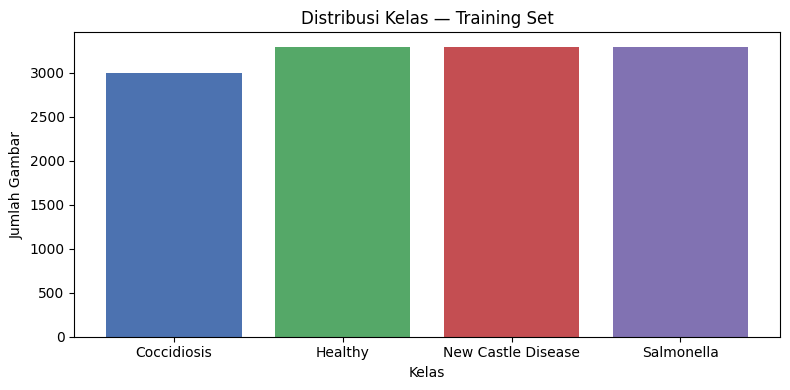

Distribusi: {'Coccidiosis': 3000, 'Healthy': 3291, 'New Castle Disease': 3293, 'Salmonella': 3293}


In [21]:
train_dir   = os.path.join(SAMPLE_PATH, 'train')
class_names = sorted(os.listdir(train_dir))
class_counts = {c: len(os.listdir(os.path.join(train_dir, c))) for c in class_names}

plt.figure(figsize=(8, 4))
plt.bar(class_counts.keys(), class_counts.values(),
        color=['#4C72B0','#55A868','#C44E52','#8172B2'])
plt.title('Distribusi Kelas — Training Set')
plt.xlabel('Kelas'); plt.ylabel('Jumlah Gambar')
plt.tight_layout(); plt.show()
print('Distribusi:', class_counts)

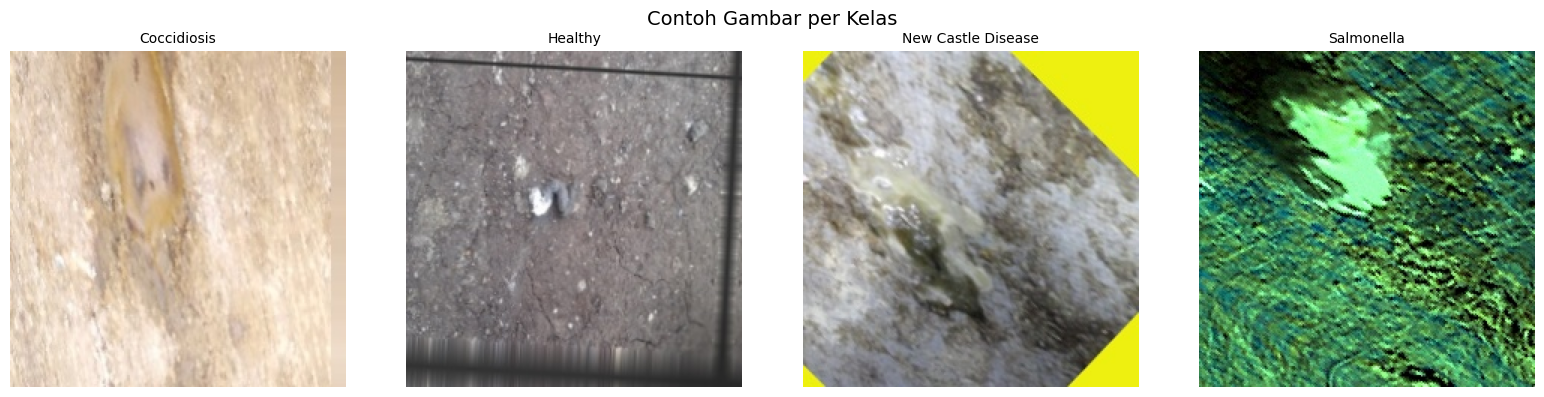

In [22]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle('Contoh Gambar per Kelas', fontsize=14)
for ax, cls in zip(axes, class_names):
    img_path = os.path.join(train_dir, cls,
                            os.listdir(os.path.join(train_dir, cls))[0])
    ax.imshow(plt.imread(img_path))
    ax.set_title(cls, fontsize=10)
    ax.axis('off')
plt.tight_layout(); plt.show()

---
## 5. Manual Feature Extraction — HOG + LBP

**HOG (Histogram of Oriented Gradients):** Menangkap pola tepi dan gradien pada gambar. Efektif untuk membedakan bentuk dan struktur visual.

**LBP (Local Binary Pattern):** Menangkap pola tekstur lokal. Efektif untuk membedakan tekstur permukaan seperti kondisi kotoran ayam.

Kedua fitur digabung (concatenate) menjadi satu vektor per gambar untuk representasi yang lebih kaya.

In [23]:
IMAGE_SIZE = (128, 128)

# HOG parameters
HOG_ORIENTATIONS  = 9
HOG_PIXELS_PER_CELL = (8, 8)
HOG_CELLS_PER_BLOCK = (2, 2)

# LBP parameters
LBP_RADIUS  = 3
LBP_N_POINTS = 8 * LBP_RADIUS  # 24 points
LBP_N_BINS  = 256

def extract_hog(image_gray):
    """Ekstrak fitur HOG dari gambar grayscale."""
    features = hog(
        image_gray,
        orientations=HOG_ORIENTATIONS,
        pixels_per_cell=HOG_PIXELS_PER_CELL,
        cells_per_block=HOG_CELLS_PER_BLOCK,
        block_norm='L2-Hys'
    )
    return features

def extract_lbp(image_gray):
    """Ekstrak fitur LBP dari gambar grayscale."""
    lbp = local_binary_pattern(image_gray, LBP_N_POINTS, LBP_RADIUS, method='uniform')
    hist, _ = np.histogram(lbp.ravel(), bins=LBP_N_BINS, range=(0, LBP_N_BINS), density=True)
    return hist

def extract_features_manual(image_path):
    """Baca gambar, resize, lalu ekstrak HOG + LBP dan gabungkan."""
    img = np.array(Image.open(image_path).convert('RGB'))
    img = resize(img, IMAGE_SIZE, anti_aliasing=True)
    gray = rgb2gray(img)

    hog_feat = extract_hog(gray)
    lbp_feat = extract_lbp(gray)

    return np.concatenate([hog_feat, lbp_feat])

print('Fungsi feature extraction siap!')
print(f'HOG params  : orientations={HOG_ORIENTATIONS}, pixels_per_cell={HOG_PIXELS_PER_CELL}')
print(f'LBP params  : radius={LBP_RADIUS}, n_points={LBP_N_POINTS}')

Fungsi feature extraction siap!
HOG params  : orientations=9, pixels_per_cell=(8, 8)
LBP params  : radius=3, n_points=24


/usr/local/lib/python3.12/dist-packages/skimage/feature/texture.py:385: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(


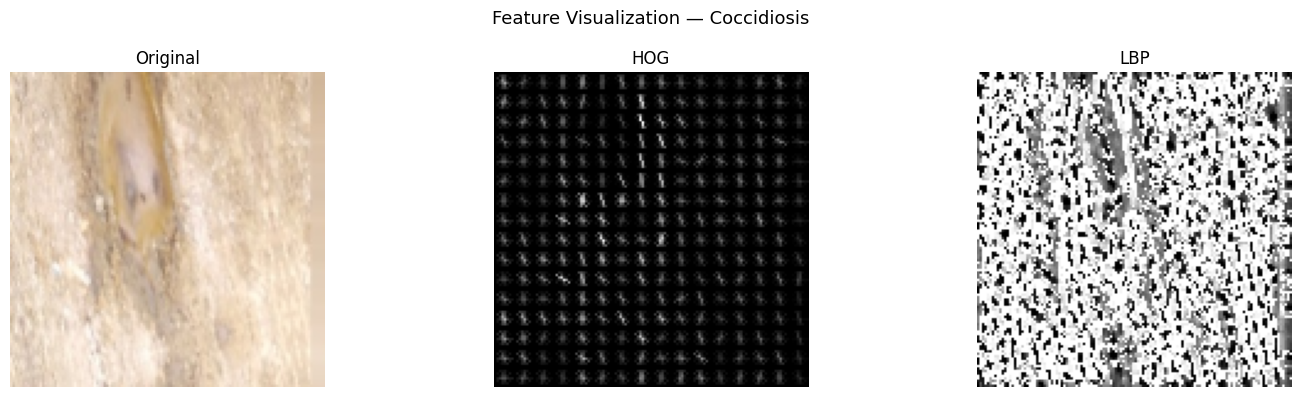

In [24]:
# Visualisasi HOG dan LBP pada contoh gambar
from skimage.feature import hog as hog_viz
from skimage import exposure

sample_cls  = class_names[0]
sample_path = os.path.join(train_dir, sample_cls,
                           os.listdir(os.path.join(train_dir, sample_cls))[0])

img   = np.array(Image.open(sample_path).convert('RGB'))
img   = resize(img, IMAGE_SIZE, anti_aliasing=True)
gray  = rgb2gray(img)

_, hog_image = hog_viz(gray, orientations=HOG_ORIENTATIONS,
                        pixels_per_cell=HOG_PIXELS_PER_CELL,
                        cells_per_block=HOG_CELLS_PER_BLOCK,
                        block_norm='L2-Hys', visualize=True)
hog_image = exposure.rescale_intensity(hog_image, in_range=(0, 10))

lbp_image = local_binary_pattern(gray, LBP_N_POINTS, LBP_RADIUS, method='uniform')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle(f'Feature Visualization — {sample_cls}', fontsize=13)
axes[0].imshow(img); axes[0].set_title('Original'); axes[0].axis('off')
axes[1].imshow(hog_image, cmap='gray'); axes[1].set_title('HOG'); axes[1].axis('off')
axes[2].imshow(lbp_image, cmap='gray'); axes[2].set_title('LBP'); axes[2].axis('off')
plt.tight_layout(); plt.show()

---
## 6. Load & Ekstrak Fitur dari Semua Split

In [25]:
def load_features_from_dir(split_dir):
    """Ekstrak fitur dan label dari semua gambar dalam direktori split."""
    features, labels = [], []
    for label_idx, class_name in enumerate(class_names):
        class_path = os.path.join(split_dir, class_name)
        img_files  = os.listdir(class_path)
        for img_file in img_files:
            img_path = os.path.join(class_path, img_file)
            try:
                feat = extract_features_manual(img_path)
                features.append(feat)
                labels.append(label_idx)
            except Exception as e:
                print(f'Skip {img_file}: {e}')
    return np.array(features), np.array(labels)

print('Mengekstrak fitur train...')
X_train, y_train = load_features_from_dir(os.path.join(SAMPLE_PATH, 'train'))
print('Mengekstrak fitur val...')
X_val,   y_val   = load_features_from_dir(os.path.join(SAMPLE_PATH, 'val'))
print('Mengekstrak fitur test...')
X_test,  y_test  = load_features_from_dir(os.path.join(SAMPLE_PATH, 'test'))

print(f'\nShape train : {X_train.shape}')
print(f'Shape test  : {X_test.shape}')

Mengekstrak fitur train...
Mengekstrak fitur val...
Mengekstrak fitur test...

Shape train : (12877, 8356)
Shape test  : (1717, 8356)


In [26]:
# Normalisasi fitur — penting untuk KNN dan SVM
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)
print('Normalisasi selesai!')

Normalisasi selesai!


---
## 7. Model 1 — KNN (K-Nearest Neighbors)

In [27]:
knn = KNeighborsClassifier(n_neighbors=5, metric='euclidean', n_jobs=-1)
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)
acc_knn    = accuracy_score(y_test, y_pred_knn)
print(f'KNN Test Accuracy: {acc_knn:.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_knn, target_names=class_names))

KNN Test Accuracy: 0.3197

Classification Report:
                    precision    recall  f1-score   support

       Coccidiosis       0.41      0.22      0.29       400
           Healthy       0.32      0.57      0.41       439
New Castle Disease       0.31      0.35      0.32       439
        Salmonella       0.26      0.13      0.17       439

          accuracy                           0.32      1717
         macro avg       0.32      0.32      0.30      1717
      weighted avg       0.32      0.32      0.30      1717



---
## 8. Model 2 — SVM (Support Vector Machine)

In [28]:
svm = SVC(kernel='rbf', C=10, gamma='scale', probability=True, random_state=42)
svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)
acc_svm    = accuracy_score(y_test, y_pred_svm)
print(f'SVM Test Accuracy: {acc_svm:.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_svm, target_names=class_names))

SVM Test Accuracy: 0.4263

Classification Report:
                    precision    recall  f1-score   support

       Coccidiosis       0.54      0.58      0.56       400
           Healthy       0.39      0.44      0.41       439
New Castle Disease       0.40      0.37      0.39       439
        Salmonella       0.37      0.32      0.34       439

          accuracy                           0.43      1717
         macro avg       0.43      0.43      0.43      1717
      weighted avg       0.42      0.43      0.42      1717



---
## 9. Confusion Matrix — Semua Model

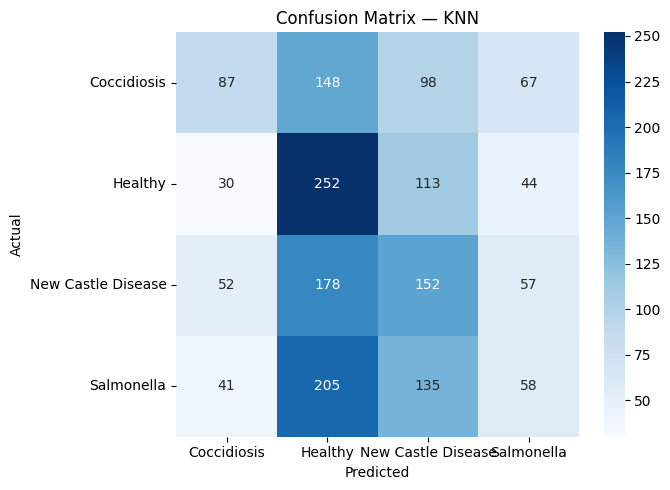

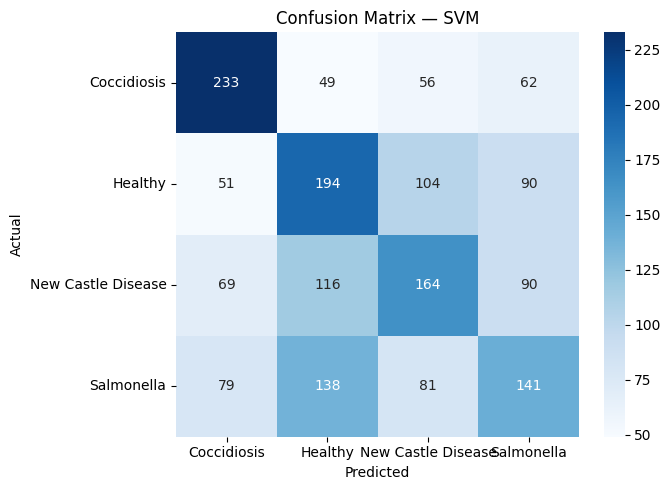

In [29]:
def plot_confusion_matrix(y_true, y_pred, title='Confusion Matrix'):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(title); plt.xlabel('Predicted'); plt.ylabel('Actual')
    plt.tight_layout(); plt.show()

plot_confusion_matrix(y_test, y_pred_knn, 'Confusion Matrix — KNN')
plot_confusion_matrix(y_test, y_pred_svm, 'Confusion Matrix — SVM')

---
## 10. Perbandingan Performa Model

Model                  Accuracy
----------------------------------------
KNN                      0.3197
SVM                      0.4263


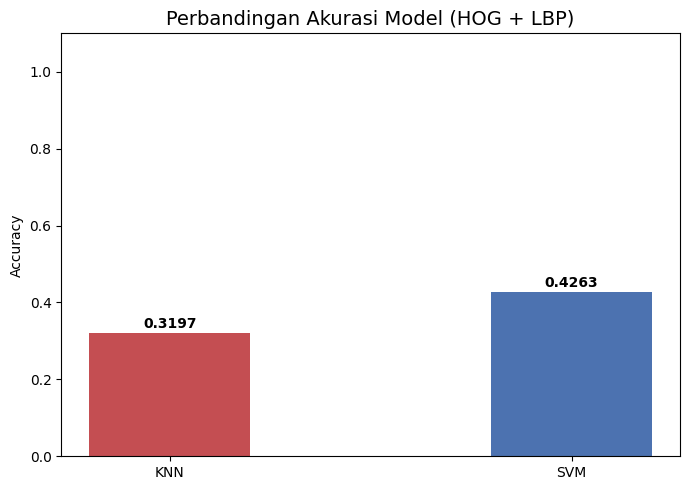

In [30]:
results = {
    'Model'   : ['KNN', 'SVM'],
    'Accuracy': [acc_knn, acc_svm]
}

print('='*40)
print(f'{"Model":<20} {"Accuracy":>10}')
print('-'*40)
for m, a in zip(results['Model'], results['Accuracy']):
    print(f'{m:<20} {a:>10.4f}')
print('='*40)

colors = ['#C44E52', '#4C72B0']
plt.figure(figsize=(7, 5))
bars = plt.bar(results['Model'], results['Accuracy'], color=colors, width=0.4)
for bar, acc in zip(bars, results['Accuracy']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{acc:.4f}', ha='center', va='bottom', fontweight='bold')
plt.ylim(0, 1.1)
plt.title('Perbandingan Akurasi Model (HOG + LBP)', fontsize=14)
plt.ylabel('Accuracy')
plt.tight_layout(); plt.show()

---
## 12. Error Rate per Kelas

**Error rate** mengukur seberapa sering model salah mengklasifikasikan gambar dari suatu kelas.

Formula: `Error Rate = 1 - Recall`


=== Error Rate per Kelas — KNN ===
  Coccidiosis           : 0.7825 (78.2%)
  Healthy               : 0.4260 (42.6%)
  New Castle Disease    : 0.6538 (65.4%)
  Salmonella            : 0.8679 (86.8%)
  Overall Error Rate    : 0.6803 (68.0%)


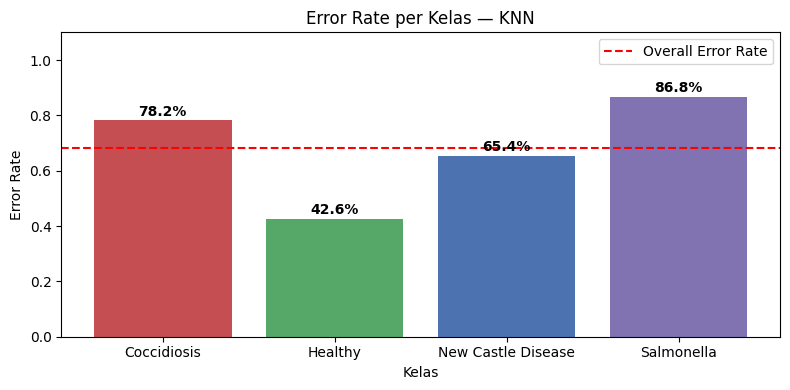


=== Error Rate per Kelas — SVM ===
  Coccidiosis           : 0.4175 (41.8%)
  Healthy               : 0.5581 (55.8%)
  New Castle Disease    : 0.6264 (62.6%)
  Salmonella            : 0.6788 (67.9%)
  Overall Error Rate    : 0.5737 (57.4%)


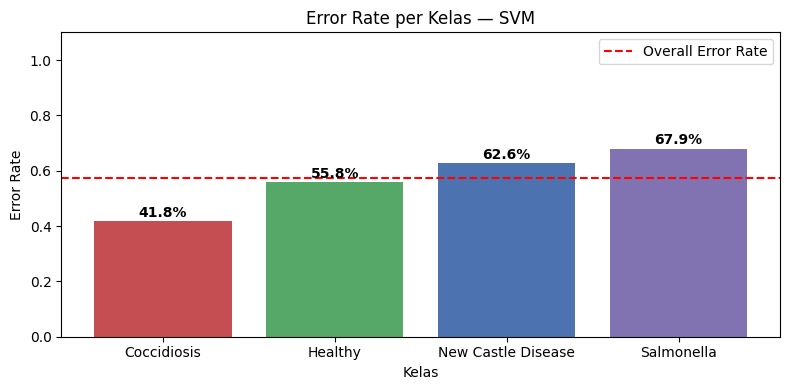

In [31]:
from sklearn.metrics import recall_score

def plot_error_rate(y_true, y_pred, model_name):
    recalls    = recall_score(y_true, y_pred, average=None)
    error_rates = 1 - recalls

    print(f'\n=== Error Rate per Kelas — {model_name} ===')
    for cls, er in zip(class_names, error_rates):
        print(f'  {cls:<22}: {er:.4f} ({er*100:.1f}%)')
    print(f'  {"Overall Error Rate":<22}: {1 - accuracy_score(y_true, y_pred):.4f} ({(1 - accuracy_score(y_true, y_pred))*100:.1f}%)')

    plt.figure(figsize=(8, 4))
    bars = plt.bar(class_names, error_rates,
                   color=['#C44E52','#55A868','#4C72B0','#8172B2'])
    for bar, er in zip(bars, error_rates):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{er*100:.1f}%', ha='center', va='bottom', fontweight='bold')
    plt.axhline(y=(1 - accuracy_score(y_true, y_pred)), color='red',
                linestyle='--', label='Overall Error Rate')
    plt.ylim(0, 1.1)
    plt.title(f'Error Rate per Kelas — {model_name}')
    plt.xlabel('Kelas')
    plt.ylabel('Error Rate')
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_error_rate(y_test, y_pred_knn, 'KNN')
plot_error_rate(y_test, y_pred_svm, 'SVM')

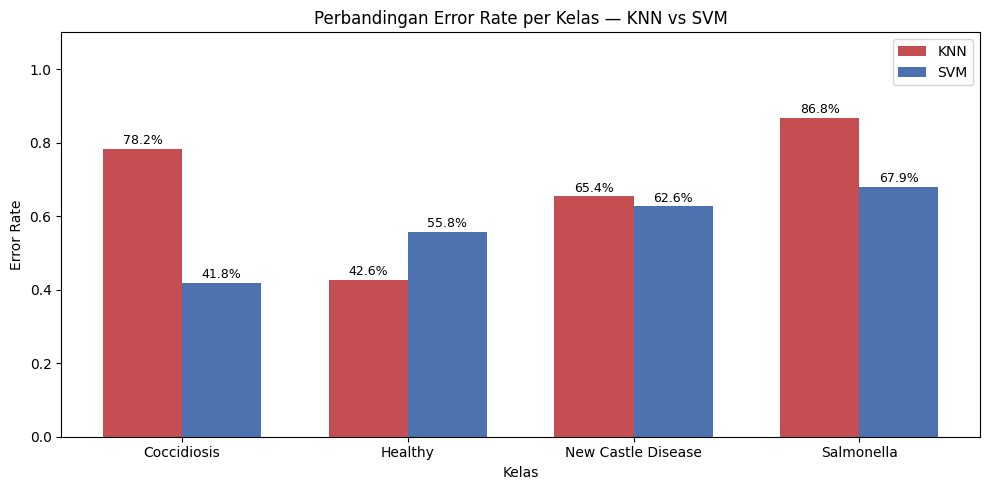

In [33]:
# Perbandingan error rate kedua model dalam satu chart
recalls_knn = recall_score(y_test, y_pred_knn, average=None)
recalls_svm = recall_score(y_test, y_pred_svm, average=None)
er_knn = 1 - recalls_knn
er_svm = 1 - recalls_svm

x     = np.arange(len(class_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, er_knn, width, label='KNN',  color='#C44E52')
bars2 = ax.bar(x + width/2, er_svm, width, label='SVM',  color='#4C72B0')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height()*100:.1f}%', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height()*100:.1f}%', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(class_names)
ax.set_ylim(0, 1.1)
ax.set_title('Perbandingan Error Rate per Kelas — KNN vs SVM')
ax.set_xlabel('Kelas')
ax.set_ylabel('Error Rate')
ax.legend()
plt.tight_layout()
plt.show()

---
## Hasil

| Model | Akurasi | Keterangan |
|---|---|---|
| KNN | *(31.97%)* | Classifier berbasis jarak |
| **SVM** | ***(42.63%)*** | **Classifier berbasis hyperplane optimal** |
